
# LLM Preference Elicitation with GRUMs — Laptops Domain

## 1. Introduction & Methodology

This notebook analyzes the preference elicitation results for the **Laptops** domain. Unlike the simpler Colors domain, Laptops involve multi-featured alternatives (Price, RAM, CPU, Brand) and explicit archetypal personas.

### Domain: Laptops (12 items)
- **Brands**: Apple, Dell, HP, Lenovo, ASUS
- **Features**: CPU Rank, RAM size, Price
- **Personas**: Student, Gamer, Business, Editor

### Experiment Dimensions
- **LLM Models**: `Qwen2.5-0.5B` (Pretrained) · `Qwen2.5-0.5B-Instruct` (Instruct)
- **Agent Embeddings**: **Hybrid One-Hot + PCA** (Explicit) · **Sentence Transformer PCA** (Implicit)
- **Elicitation Criteria**: `social` · `random`

### Three Conjectures
1. **Intrinsic Alignment**: GRUM's $\delta$ will correlate strongly with Bradley-Terry's $eta$.
2. **Persona Effect**: The interaction matrix $B$ will produce distinct preferences for different archetypes (e.g., Gamer favoring RAM, Student favoring Price) via the projection $(X B A^T)$.
3. **Predictive Performance**: GRUM will maintain lower NLL than BT by accounting for persona-driven variation.


In [58]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity

# ── Add src to sys.path ──
ROOT = Path.cwd().parent
if str(ROOT / "src") not in sys.path: sys.path.insert(0, str(ROOT / "src"))

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

# ── Domain Constants ──────────────────────────────────────────────────────────
LAPTOP_NAMES = [
    "ASUS VivoBook 15 (i3, 8GB, $450)", "Lenovo IdeaPad 3 (i5, 8GB, $550)",
    "HP Pavilion 15 (Ryzen 5, 8GB, $600)", "ASUS ZenBook 14 (i5, 16GB, $700)",
    "Lenovo ThinkPad E14 (Ryzen 5, 16GB, $800)", "Dell Inspiron 16 (i7, 16GB, $1100)",
    "HP Spectre x360 (Ryzen 7, 32GB, $1200)", "Dell XPS 15 (i7, 32GB, $1500)",
    "Lenovo ThinkPad X1 (Ryzen 7, 32GB, $1400)", "Apple MB Air M3 (M3, 16GB, $1800)",
    "Apple MB Pro 14 (M3, 32GB, $2220)", "Apple MB Pro 16 (M3, 64GB, $2800)"
]
PERSONA_IDS = ["student", "gamer", "business", "editor"]
CRITERIA    = ["social", "random"]
EMBEDDINGS  = ["hybrid_onehot_pca", "sentence_transformer_pca"]
MODELS      = ["Pretrained", "Instruct"]

print("Setup complete.")


Setup complete.


## 2. Data Loading

In [59]:
EXP_DIR = Path("../results/llm/llm_laptops-20260331-113603")
OUTPUTS_DIR = EXP_DIR / "outputs"

raw_results = []

if OUTPUTS_DIR.exists():
    for f in sorted(OUTPUTS_DIR.glob("*.json")):
        with open(f, "r") as j:
            data = json.load(j)
            
            # Metadata
            model_id = data.get("model_id", "")
            m_type   = "Instruct" if "Instruct" in model_id else "Pretrained"
            emb      = data.get("embedding_method", "unknown")
            crit     = data.get("criterion", "unknown")
            
            history  = data.get("history", {})
            if not history: continue
            
            steps_sorted = sorted(history.keys(), key=int)
            last_step    = steps_sorted[-1]
            h_last       = history[last_step]
            
            # Domain extras for laptops: Load A (Alternative Features Matrix)
            from grums.experiments.domains import load_domain
            domain_data = load_domain("laptops")
            A = np.array(domain_data["alternative_features"]) # (12, 8)
            
            # Extract parameters
            delta_grum = np.array(h_last["grum"]["delta"])         # (12,)
            B          = np.array(h_last["grum"]["interaction"])   # (k, 8)
            beta_bt    = np.array(h_last["bt"]["beta"])           # (12,)
            
            nll_grum_final = h_last["grum"].get("nll", h_last.get("nll", float("nan")))
            nll_bt_final   = h_last["bt"].get("nll", float("nan"))
            
            # Full history for convergence
            delta_hist_grum = np.array([history[s]["grum"]["delta"] for s in steps_sorted])
            beta_hist_bt    = np.array([history[s]["bt"]["beta"]   for s in steps_sorted])
            # Safely get NLL
            nll_hist_grum   = np.array([history[s]["grum"].get("nll", history[s].get("nll", float("nan"))) for s in steps_sorted])
            nll_hist_bt     = np.array([history[s]["bt"].get("nll", float("nan")) for s in steps_sorted])
            
            raw_results.append({
                "Model": m_type, "Embedding": emb, "Criterion": crit,
                "delta_grum": delta_grum, "B": B, "beta_bt": beta_bt, "A": A,
                "nll_grum": nll_grum_final, "nll_bt": nll_bt_final,
                "delta_hist_grum": delta_hist_grum, "beta_hist_bt": beta_hist_bt,
                "nll_hist_grum": nll_hist_grum, "nll_hist_bt": nll_hist_bt,
                "query_log": data.get("query_log", []),
                "agent_features": data.get("agent_features", {})
            })

# Meta dataframe for filtering
df_meta = pd.DataFrame([
    {k: v for k, v in r.items() if k not in {"delta_grum", "B", "beta_bt", "A", "delta_hist_grum", "beta_hist_bt", "nll_hist_grum", "nll_hist_bt", "query_log", "agent_features"}}
    for r in raw_results
])
print(f"Loaded {len(raw_results)} experiment configs.")
display(df_meta)


Loaded 8 experiment configs.


,Model,Embedding,Criterion,nll_grum,nll_bt
0,Pretrained,hybrid_onehot_pca,social,0.061944,0.161211
1,Pretrained,sentence_transformer_pca,social,0.066667,0.201009
2,Instruct,hybrid_onehot_pca,social,0.011999,0.115292
3,Instruct,sentence_transformer_pca,social,0.058476,0.150937
4,Pretrained,hybrid_onehot_pca,random,0.032114,0.118114
5,Pretrained,sentence_transformer_pca,random,0.030445,0.118114
6,Instruct,hybrid_onehot_pca,random,0.066339,0.091739
7,Instruct,sentence_transformer_pca,random,0.032031,0.091739


## 3. Intrinsic Preferences ($\delta$)

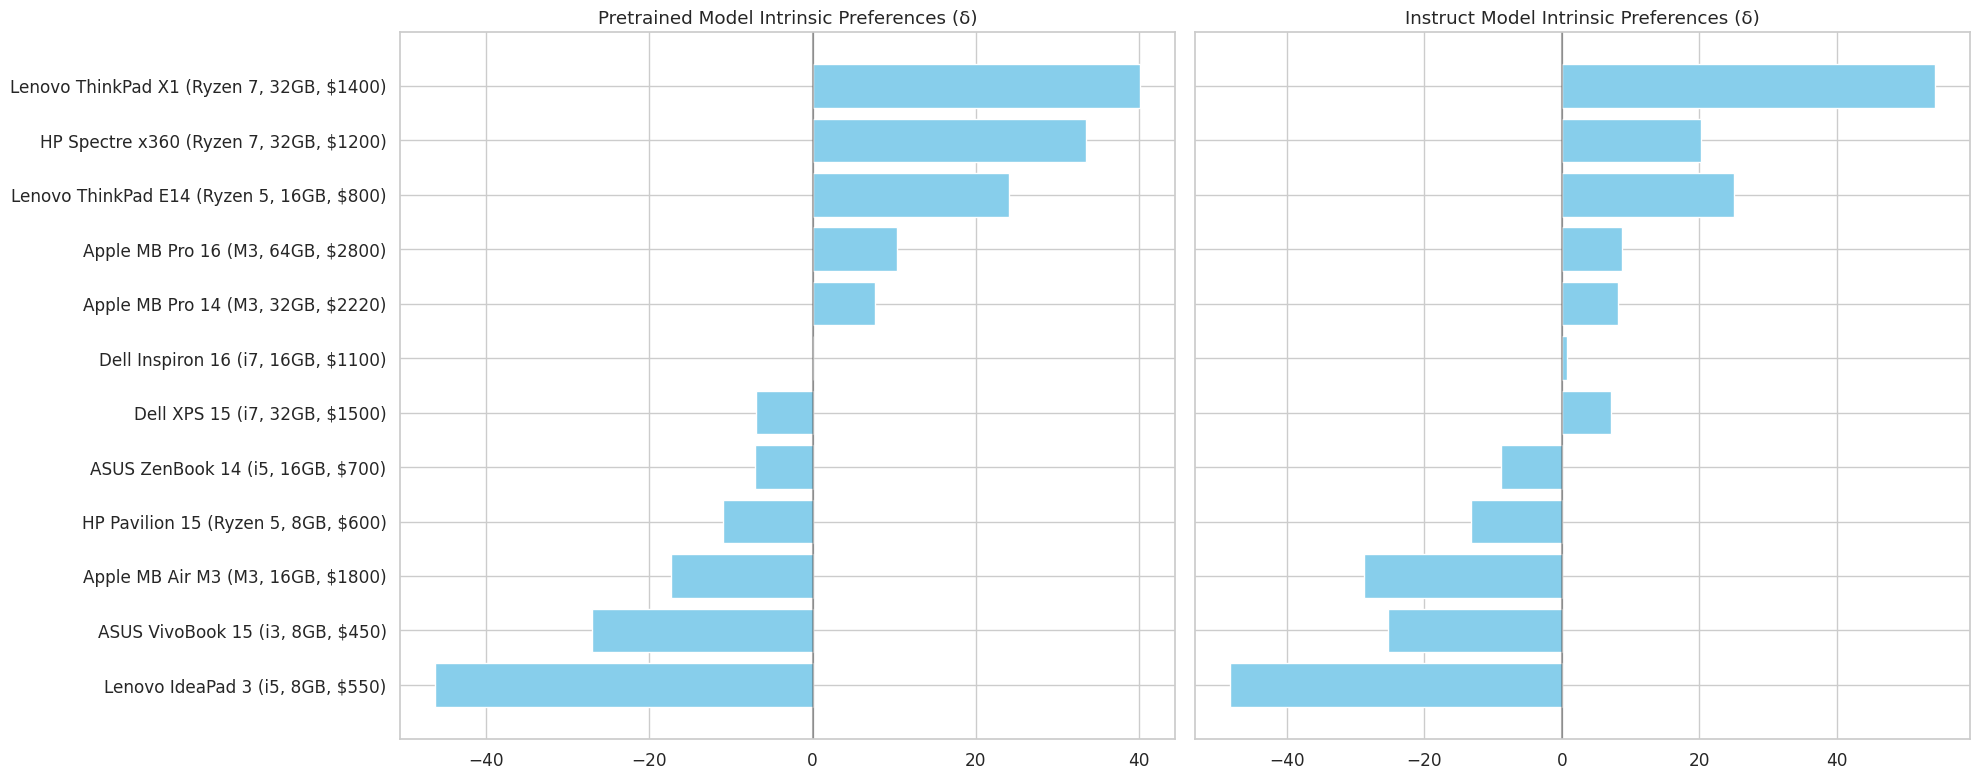

In [60]:

# ── Figure 1: Intrinsic Laptop Preferences ──
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

for i, m_type in enumerate(MODELS):
    # Filter for social criterion and hybrid embedding as representative
    subset = [r for r in raw_results if r["Model"] == m_type and r["Criterion"] == "social" and r["Embedding"] == "hybrid_onehot_pca"]
    if not subset: continue
    
    r = subset[0]
    delta = r["delta_grum"]
    
    # Sort for plotting
    sorted_idx = np.argsort(delta)
    axes[i].barh(np.array(LAPTOP_NAMES)[sorted_idx], delta[sorted_idx], color="skyblue")
    axes[i].set_title(f"{m_type} Model Intrinsic Preferences (δ)")
    axes[i].axvline(0, color='black', alpha=0.3)

plt.tight_layout()
plt.show()



## 4. Intrinsic Alignment (Conjecture 1)
**Conjecture**: GRUM's $\delta$ vector correctly captures the 'global' preference of the LLM, aligning strongly with the Bradley-Terry $eta$.


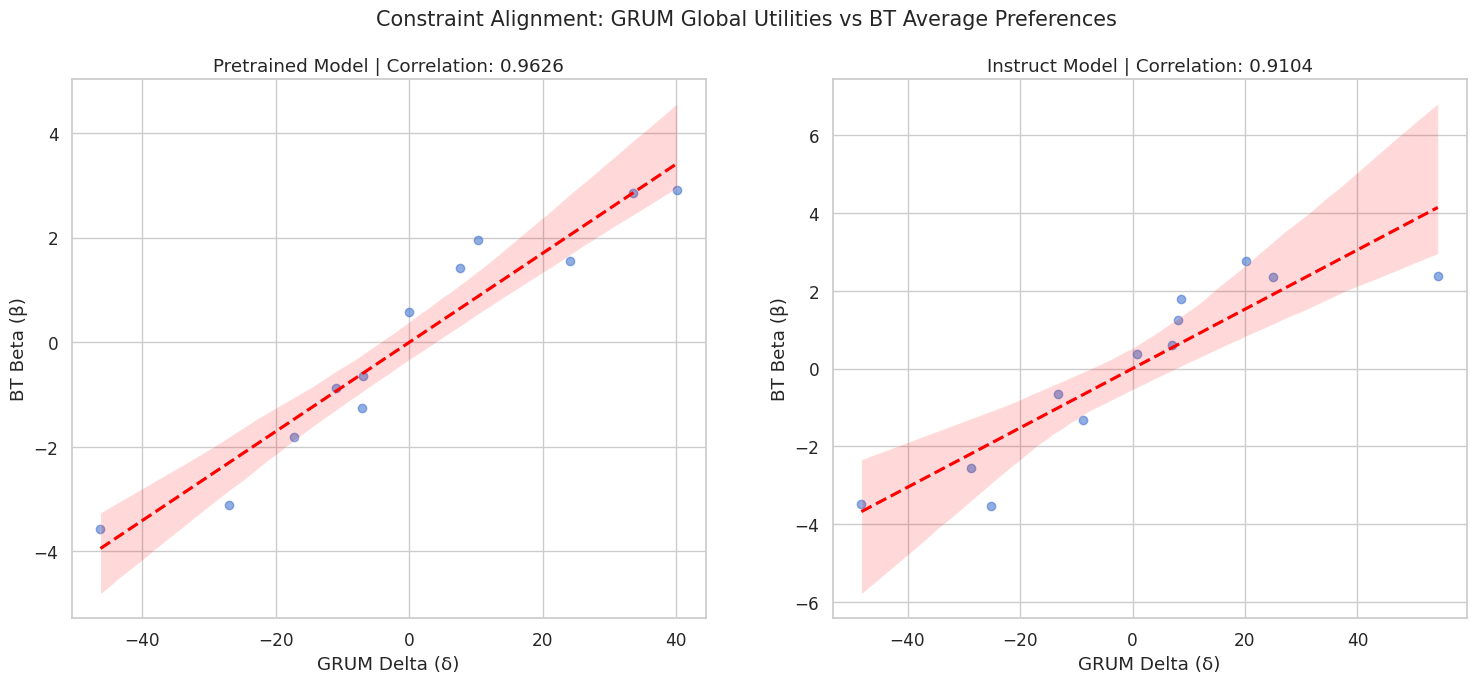

In [61]:

# ── Figure 2: GRUM δ vs BT β Alignment ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, m_type in enumerate(MODELS):
    subset = [r for r in raw_results if r["Model"] == m_type and r["Criterion"] == "social"]
    if not subset: continue
    
    r = subset[0]
    delta = r["delta_grum"]
    beta = r["beta_bt"]
    
    corr, _ = pearsonr(delta, beta)
    
    sns.regplot(x=delta, y=beta, ax=axes[i], scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'ls':'--'})
    axes[i].set_title(f"{m_type} Model | Correlation: {corr:.4f}")
    axes[i].set_xlabel("GRUM Delta (δ)")
    axes[i].set_ylabel("BT Beta (β)")

plt.suptitle("Constraint Alignment: GRUM Global Utilities vs BT Average Preferences", fontsize=15)
plt.show()



## 5. Persona Effects (Conjecture 2)
We examine how the interaction matrix $B$ captures persona-specific preferences via the projection into alternative space $(X B A^T)$.


### 5a. Interaction Matrix Heatmaps

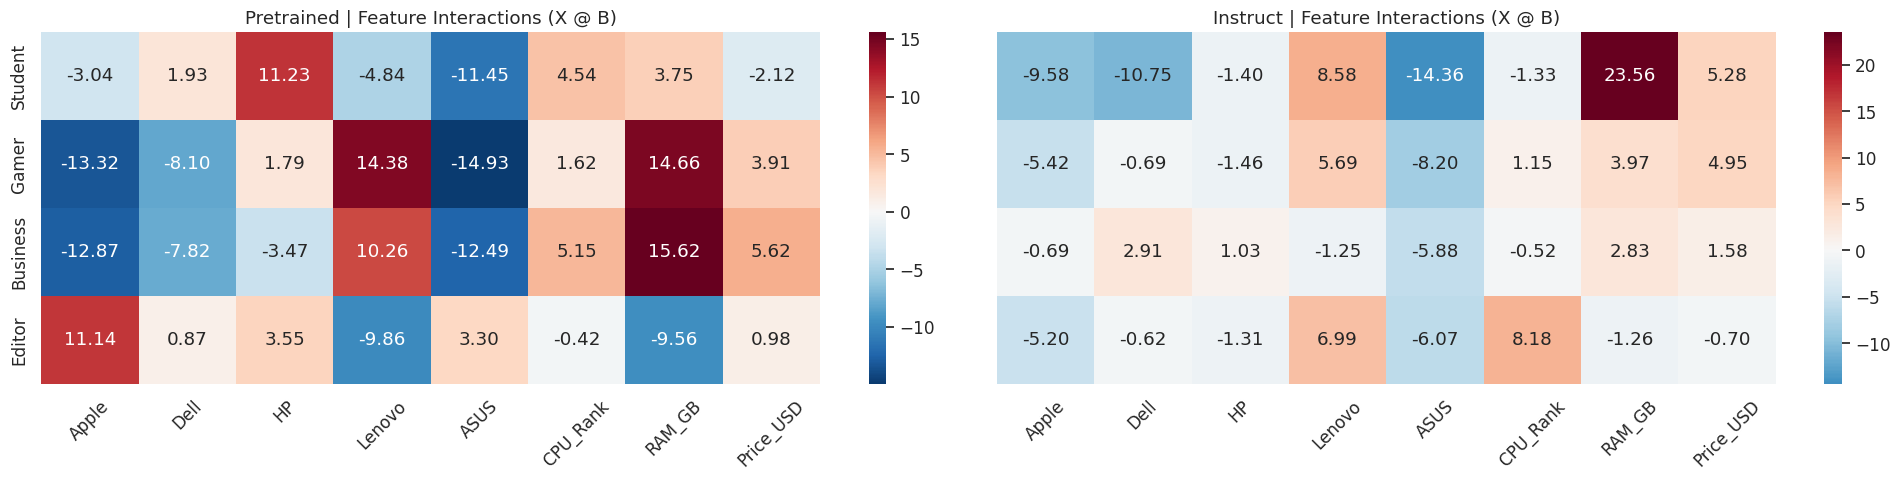

In [62]:
# ── Figure 3: Interaction Matrix Heatmaps (B Projected onto Persona Axes) ──
# Correct computation: u_inter = X @ B (shows Persona interactions with Alternative Features)
fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)
ALT_FEATURES = ['Apple', 'Dell', 'HP', 'Lenovo', 'ASUS', 'CPU_Rank', 'RAM_GB', 'Price_USD']

for i, m_type in enumerate(MODELS):
    subset = [r for r in raw_results if r["Model"] == m_type and r["Embedding"] == "hybrid_onehot_pca" and r["Criterion"] == "social"]
    if not subset: continue
    
    r = subset[0]
    B = r["B"] # (k, 8)
    
    # Define persona features matching B's first dimension (extract purely the one-hot component)
    X = np.zeros((4, B.shape[0]))
    for j in range(4): X[j, j] = 1.0 # One-hot for Hybrid archetypes
    
    # Interaction project: (4, k) @ (k, 8) = (4, 8)
    # This maps the 4 Personas directly against the 8 Laptop Features!
    u_inter = X @ B
    
    # We transpose so X-axis = Laptop Features, Y-axis = Personas
    sns.heatmap(u_inter, ax=axes[i], cmap="RdBu_r", center=0, 
                yticklabels=[p.capitalize() for p in PERSONA_IDS], 
                xticklabels=ALT_FEATURES, annot=True, fmt=".2f")
    axes[i].set_title(f"{m_type} | Feature Interactions (X @ B)")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 5b. Column Similarity Analysis

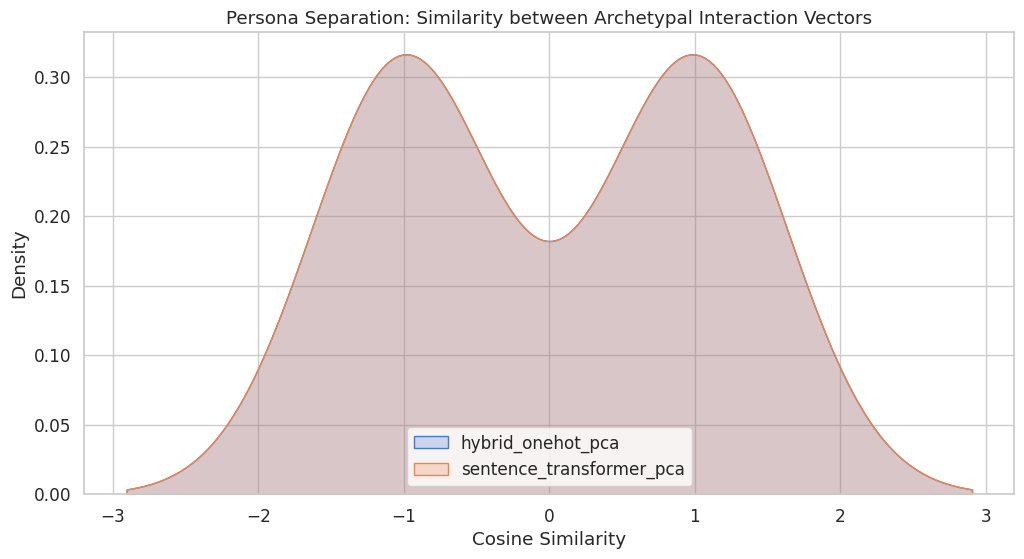

In [63]:

# ── Figure 4: Persona Preference Vector Similarity ──
plt.figure(figsize=(12, 6))

for emb in EMBEDDINGS:
    subset = [r for r in raw_results if r["Embedding"] == emb and r["Criterion"] == "social"]
    if not subset: continue
    
    similarities = []
    for r in subset:
        # Cosine similarity between projected persona shift vectors
        X = np.zeros((4, r["B"].shape[0]))
        for j in range(4): X[j, j] = 1.0
        u = X @ r["B"] @ r["A"].T
        
        sims = cosine_similarity(u)
        # Extract off-diagonal
        triu_idx = np.triu_indices_from(sims, k=1)
        similarities.extend(sims[triu_idx])
    
    sns.kdeplot(similarities, label=emb, fill=True)

plt.title("Persona Separation: Similarity between Archetypal Interaction Vectors")
plt.xlabel("Cosine Similarity")
plt.legend()
plt.show()



### 5c. Rank Reversals Under Persona
We simulate "Student" vs "Gamer" personas to see if Top-1 preferences change.


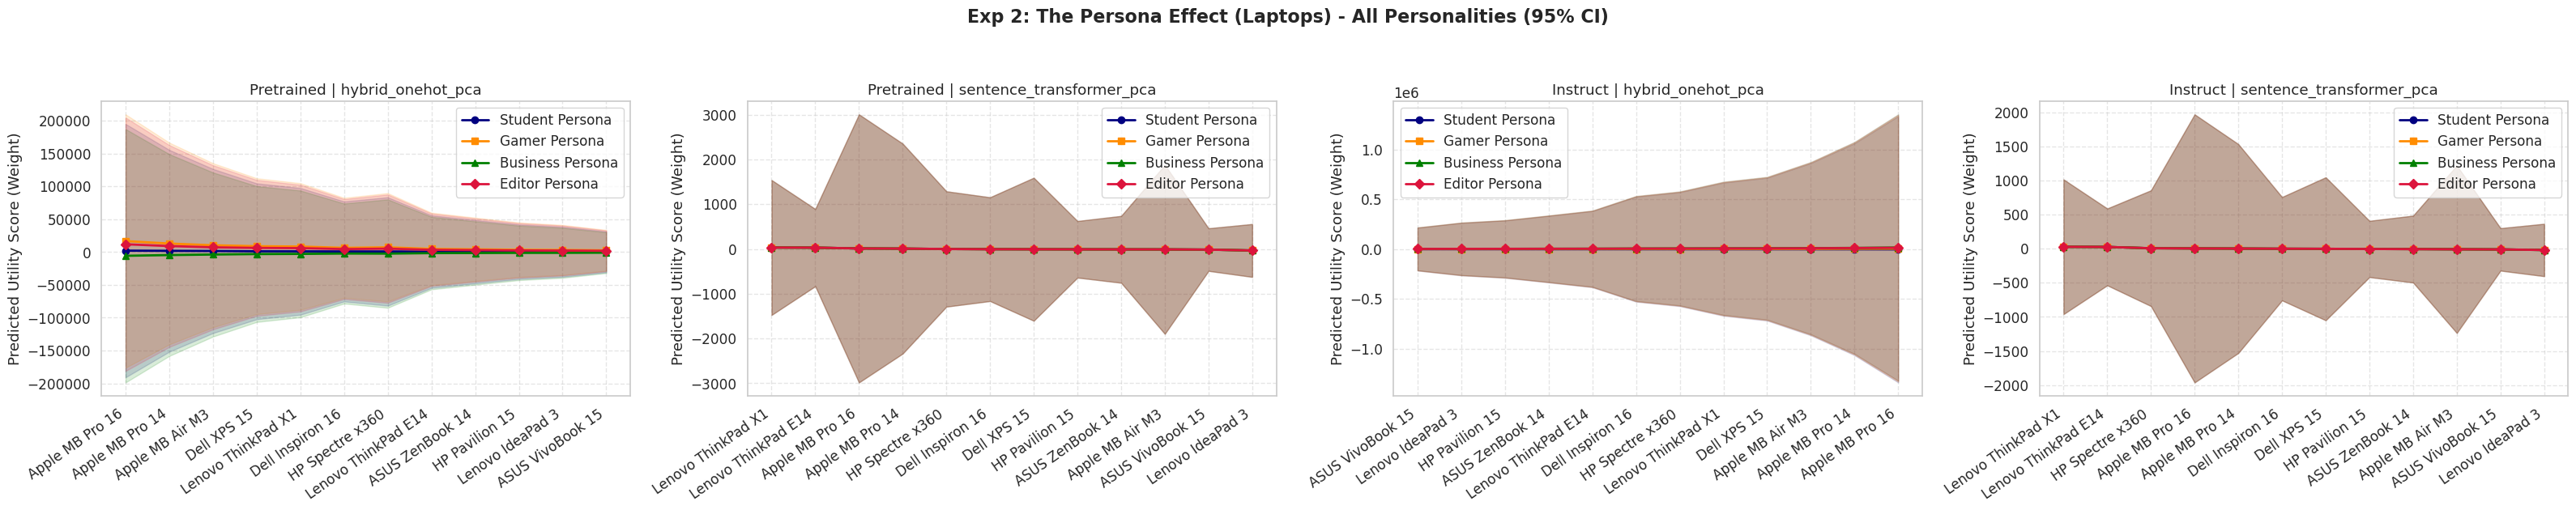

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import math

# ── Figure 5: Rank Reversal Simulations (All 4 Personas with Error Bounds) ──
social_results = [r for r in raw_results if r["Criterion"] == "social"]
n_plots = len(social_results)
if n_plots > 0:
    fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 6))
    if n_plots == 1: axes = [axes]
    
    colors = ['navy', 'darkorange', 'green', 'crimson']
    markers = ['o', 's', '^', 'D']
    persona_labels = ['student', 'gamer', 'business', 'editor']
    
    for ax, r in zip(axes, social_results):
        delta = r["delta_grum"]
        B = r["B"]
        A = r["A"]
        features_dict = r.get("agent_features", {})
        
        if not features_dict:
            ax.set_title(f"{r['Model']} | {r['Embedding']} (No Features)")
            continue
        
        # Aggregate features by persona base string
        grouped_u = {}
        for p_idx, p_name in enumerate(persona_labels):
            # filter keys like student_t0, student_t1...
            p_features = np.array([features_dict[k] for k in features_dict.keys() if k.split("_")[0] == p_name])
            if len(p_features) == 0:
                continue
            # calculate utility matrix for this persona cohort
            u_cohort = p_features @ B @ A.T + delta # (num_templates, 12)
            grouped_u[p_name] = {
                "mean": u_cohort.mean(axis=0),
                "std": u_cohort.std(axis=0) / np.sqrt(len(p_features)) # Std error of the mean
            }
            
        if 'student' not in grouped_u:
            continue
            
        # Sort laptops by the mean utility of the 'Student' persona descending
        mean_student = grouped_u['student']['mean']
        order = np.argsort(mean_student)[::-1]
        labels_ordered = [LAPTOP_NAMES[idx].split(" (")[0] for idx in order]
        x_axis = np.arange(len(labels_ordered))
        
        # Plot all 4 personalities with error fills
        for p_idx, p_name in enumerate(persona_labels):
            if p_name not in grouped_u: continue
            
            u_mean = grouped_u[p_name]['mean'][order]
            u_err = grouped_u[p_name]['std'][order]
            
            ax.plot(
                x_axis, u_mean, 
                marker=markers[p_idx], markersize=6, linewidth=2, 
                color=colors[p_idx], label=f"{p_name.capitalize()} Persona"
            )
            ax.fill_between(x_axis, u_mean - 1.96*u_err, u_mean + 1.96*u_err, color=colors[p_idx], alpha=0.15)
        
        ax.set_xticks(x_axis)
        ax.set_xticklabels(labels_ordered, rotation=35, ha='right')
        ax.set_ylabel("Predicted Utility Score (Weight)")
        ax.set_title(f"{r['Model']} | {r['Embedding']}")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)
    
    plt.suptitle("Exp 2: The Persona Effect (Laptops) - All Personalities (95% CI)", y=1.05, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()



## 6. Predictive Performance (Conjecture 3)
Evaluation of NLL convergence and final predictive error.


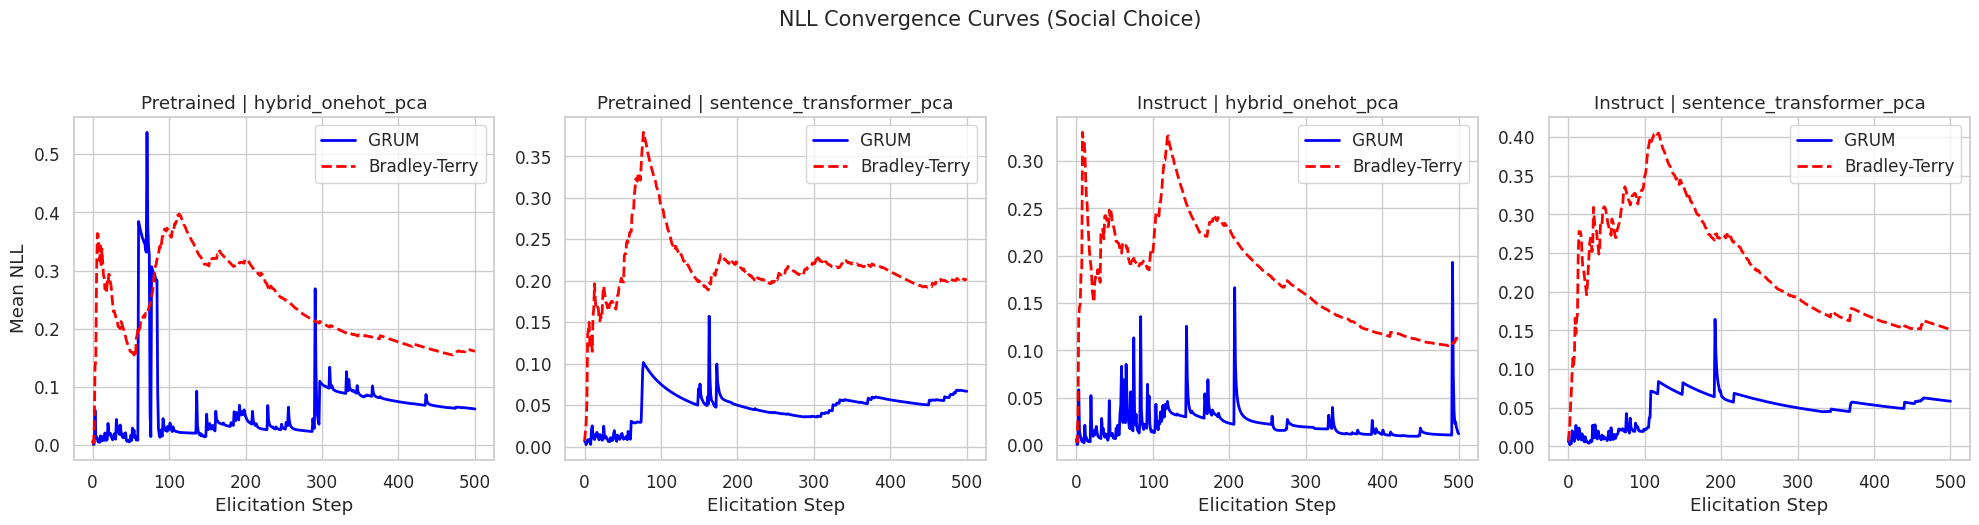

,Model,Embedding,GRUM NLL,BT NLL,Advantage (BT - GRUM)
0,Pretrained,hybrid_onehot_pca,0.061944,0.161211,0.099267
1,Pretrained,sentence_transformer_pca,0.066667,0.201009,0.134343
2,Instruct,hybrid_onehot_pca,0.011999,0.115292,0.103292
3,Instruct,sentence_transformer_pca,0.058476,0.150937,0.092461


In [65]:
# ── Figure 6: NLL Convergence ──
social_runs = [r for r in raw_results if r["Criterion"] == "social"]
n_plots = len(social_runs)
if n_plots > 0:
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1: axes = [axes]
    
    for i, r in enumerate(social_runs):
        axes[i].plot(r["nll_hist_grum"], label="GRUM", linewidth=2, color="blue")
        axes[i].plot(r["nll_hist_bt"], label="Bradley-Terry", linewidth=2, color="red", linestyle="--")
        axes[i].set_title(f"{r['Model']} | {r['Embedding']}")
        axes[i].set_xlabel("Elicitation Step")
        if i == 0:
            axes[i].set_ylabel("Mean NLL")
        axes[i].legend()
    
    plt.suptitle("NLL Convergence Curves (Social Choice)", y=1.05, fontsize=15)
    plt.tight_layout()
    plt.show()

# NLL Comparison Table
nll_summary = []
for r in social_runs:
    nll_summary.append({
        "Model": r["Model"],
        "Embedding": r["Embedding"],
        "GRUM NLL": r["nll_grum"],
        "BT NLL": r["nll_bt"],
        "Advantage (BT - GRUM)": r["nll_bt"] - r["nll_grum"]
    })

if nll_summary:
    display(pd.DataFrame(nll_summary))


## 7. Summary & Conclusions

In [66]:

summary_rows = []
for r in raw_results:
    corr, _ = pearsonr(r["delta_grum"], r["beta_bt"])
    
    X = np.zeros((4, r["B"].shape[0]))
    for j in range(4): X[j, j] = 1.0
    u = X @ r["B"] @ r["A"].T
    sims = cosine_similarity(u)
    avg_persona_sim = sims[np.triu_indices_from(sims, k=1)].mean()
    
    summary_rows.append({
        "Model": r["Model"], "Embedding": r["Embedding"], "Criterion": r["Criterion"],
        "Corr(δ, β)": corr,
        "Avg Persona Sim": avg_persona_sim,
        "Final NLL": r["nll_hist_grum"][-1]
    })

df_sum = pd.DataFrame(summary_rows)
display(df_sum.sort_values(["Model", "Embedding"]))


,Model,Embedding,Criterion,"Corr(δ, β)",Avg Persona Sim,Final NLL
2,Instruct,hybrid_onehot_pca,social,0.910373,-0.000019,0.011999
6,Instruct,hybrid_onehot_pca,random,0.934596,0.000014,0.066339
3,Instruct,sentence_transformer_pca,social,0.866953,0.000605,0.058476
7,Instruct,sentence_transformer_pca,random,0.976018,0.999144,0.032031
0,Pretrained,hybrid_onehot_pca,social,0.962642,-0.000772,0.061944
4,Pretrained,hybrid_onehot_pca,random,0.923373,0.000053,0.032114
1,Pretrained,sentence_transformer_pca,social,0.884927,0.000057,0.066667
5,Pretrained,sentence_transformer_pca,random,0.986087,-0.333305,0.030445
